# Task 1a — Roasting Process: Linear Regression Model

Predict **product quality** from temperature, moisture and thickness measurements using a linear regression model.

- **Train set:** first 24 000 rows
- **Validation set:** remaining rows
- **Evaluation metric:** Mean Absolute Error (MAE)
- **Plot:** predicted vs actual quality for the last 500 rows of validation data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load and Inspect the Data

In [11]:
df = pd.read_csv('roasting_data.csv', parse_dates=['date_time'])

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (29001, 19)

Column names:
['date_time', 'T_data_1_1', 'T_data_1_2', 'T_data_1_3', 'T_data_2_1', 'T_data_2_2', 'T_data_2_3', 'T_data_3_1', 'T_data_3_2', 'T_data_3_3', 'T_data_4_1', 'T_data_4_2', 'T_data_4_3', 'T_data_5_1', 'T_data_5_2', 'T_data_5_3', 'H_data', 'AH_data', 'quality']

First 5 rows:


,date_time,T_data_1_1,T_data_1_2,T_data_1_3,T_data_2_1,T_data_2_2,T_data_2_3,T_data_3_1,T_data_3_2,T_data_3_3,T_data_4_1,T_data_4_2,T_data_4_3,T_data_5_1,T_data_5_2,T_data_5_3,H_data,AH_data,quality
0,2015-01-04 00:00:00,277.583333,300.366667,273.550000,320.483333,331.966667,355.450000,501.900000,501.650000,705.516667,330.233333,387.133333,336.316667,231.850000,237.683333,236.516667,156.446500,7.90,392.0
1,2015-01-04 01:00:00,273.600000,231.833333,266.800000,322.700000,334.216667,347.133333,501.133333,500.366667,579.600000,341.550000,398.683333,334.350000,237.016667,245.683333,231.966667,156.000167,6.96,384.0
2,2015-01-04 02:00:00,250.333333,227.033333,256.350000,326.583333,333.666667,317.716667,511.183333,498.116667,492.366667,345.350000,395.066667,332.233333,248.850000,254.150000,244.783333,156.047000,7.29,393.0
3,2015-01-04 03:00:00,240.400000,239.350000,249.250000,325.750000,325.400000,310.500000,522.683333,498.966667,538.716667,341.283333,379.883333,337.816667,260.000000,260.516667,248.550000,188.481667,7.11,399.0
4,2015-01-04 04:00:00,227.366667,231.133333,235.866667,320.233333,317.183333,320.066667,516.683333,504.433333,515.666667,345.583333,365.300000,345.883333,265.866667,264.950000,273.866667,194.080500,7.97,400.0


In [12]:
print('Summary statistics:')
df.describe()

Summary statistics:


,date_time,T_data_1_1,T_data_1_2,T_data_1_3,T_data_2_1,T_data_2_2,T_data_2_3,T_data_3_1,T_data_3_2,T_data_3_3,T_data_4_1,T_data_4_2,T_data_4_3,T_data_5_1,T_data_5_2,T_data_5_3,H_data,AH_data,quality
count,29001,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000,29001.000000
mean,2016-09-03 07:07:26.757008384,250.181355,249.853390,250.205083,350.381225,350.146327,350.095262,501.337629,501.190197,501.329362,349.177811,349.416368,349.987648,249.849805,249.723887,249.909898,174.707198,7.499821,402.869039
min,2015-01-04 00:00:00,0.066667,6.733333,7.350000,3.666667,15.016667,0.716667,7.983333,10.400000,1.050000,10.250000,27.733333,24.483333,9.016667,0.433333,2.866667,149.357000,3.120000,221.000000
25%,2015-11-04 22:00:00,228.616667,228.583333,228.933333,328.550000,328.150000,328.600000,463.800000,463.466667,464.116667,326.916667,327.416667,327.816667,228.700000,228.783333,228.750000,163.139333,6.730000,372.000000
50%,2016-09-03 17:00:00,249.850000,249.750000,249.916667,350.116667,349.583333,349.983333,501.800000,501.850000,502.000000,348.933333,349.000000,349.466667,249.600000,249.800000,249.816667,174.338667,7.510000,408.000000
75%,2017-07-04 09:00:00,271.533333,271.233333,271.450000,371.833333,371.933333,371.633333,537.383333,536.933333,538.166667,370.950000,370.866667,371.433333,270.383333,270.816667,270.616667,186.189167,8.280000,439.000000
max,2018-05-03 23:00:00,711.566667,561.483333,647.450000,1278.683333,1135.183333,858.250000,1544.983333,2459.200000,1224.416667,1148.450000,1211.850000,877.950000,859.716667,638.383333,618.383333,200.660000,11.620000,505.000000
std,NaN,30.970083,29.597831,29.706509,38.126330,36.486872,36.195960,58.984647,60.446330,59.072362,36.246978,35.706192,36.071992,29.940666,29.516344,29.718627,13.792923,1.147219,46.240782


In [13]:
print(f'Missing values per column:')
print(df.isnull().sum())

Missing values per column:
date_time     0
T_data_1_1    0
T_data_1_2    0
T_data_1_3    0
T_data_2_1    0
T_data_2_2    0
T_data_2_3    0
T_data_3_1    0
T_data_3_2    0
T_data_3_3    0
T_data_4_1    0
T_data_4_2    0
T_data_4_3    0
T_data_5_1    0
T_data_5_2    0
T_data_5_3    0
H_data        0
AH_data       0
quality       0
dtype: int64


## 2. Define Input Features and Target

The dataset contains three sensor groups:
- **Temperature** — columns `T_data_*` (5 zones × 3 sensors = 15 columns)
- **Moisture** — column `H_data` (relative humidity)
- **Thickness** — column `AH_data` (absolute humidity, used as thickness proxy)

**Target:** `quality`

In [14]:
# Temperature columns (all T_data_* columns)
temperature_cols = [c for c in df.columns if c.startswith('T_data')]

# Moisture and thickness columns
moisture_col  = ['H_data']   # relative humidity → moisture
thickness_col = ['AH_data']  # absolute humidity → thickness proxy

feature_cols = temperature_cols + moisture_col + thickness_col
target_col   = 'quality'

print(f'Number of temperature features : {len(temperature_cols)}')
print(f'Moisture feature               : {moisture_col}')
print(f'Thickness feature              : {thickness_col}')
print(f'Total input features           : {len(feature_cols)}')
print(f'Target                         : {target_col}')

Number of temperature features : 15
Moisture feature               : ['H_data']
Thickness feature              : ['AH_data']
Total input features           : 17
Target                         : quality


## 3. Train / Validation Split

In [15]:
TRAIN_SIZE = 24_000

train_df = df.iloc[:TRAIN_SIZE].copy()
val_df   = df.iloc[TRAIN_SIZE:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val   = val_df[feature_cols]
y_val   = val_df[target_col]

print(f'Training rows   : {len(X_train):>6,}')
print(f'Validation rows : {len(X_val):>6,}')

Training rows   : 24,000
Validation rows :  5,001


## 4. Train Linear Regression Model

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained.')
print(f'Intercept : {model.intercept_:.4f}')
print(f'\nFeature coefficients:')
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

Model trained.
Intercept : 449.9317

Feature coefficients:
   feature  coefficient
    H_data     0.519262
T_data_3_3    -0.263578
T_data_3_1    -0.238460
T_data_3_2    -0.221359
T_data_5_3     0.144022
T_data_5_2     0.127179
   AH_data    -0.121949
T_data_5_1     0.118646
T_data_1_2     0.118103
T_data_1_3     0.103713
T_data_1_1     0.083458
T_data_2_2     0.059641
T_data_2_3     0.052312
T_data_2_1     0.039962
T_data_4_3    -0.015270
T_data_4_1     0.012676
T_data_4_2    -0.000609


## 5. Evaluate — Mean Absolute Error

In [17]:
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val,   y_val_pred)

print(f'Mean Absolute Error — Train      : {mae_train:.4f}')
print(f'Mean Absolute Error — Validation : {mae_val:.4f}')

Mean Absolute Error — Train      : 15.7661
Mean Absolute Error — Validation : 16.0166


## 6. Plot Predicted vs Actual Quality (Last 500 Validation Rows)

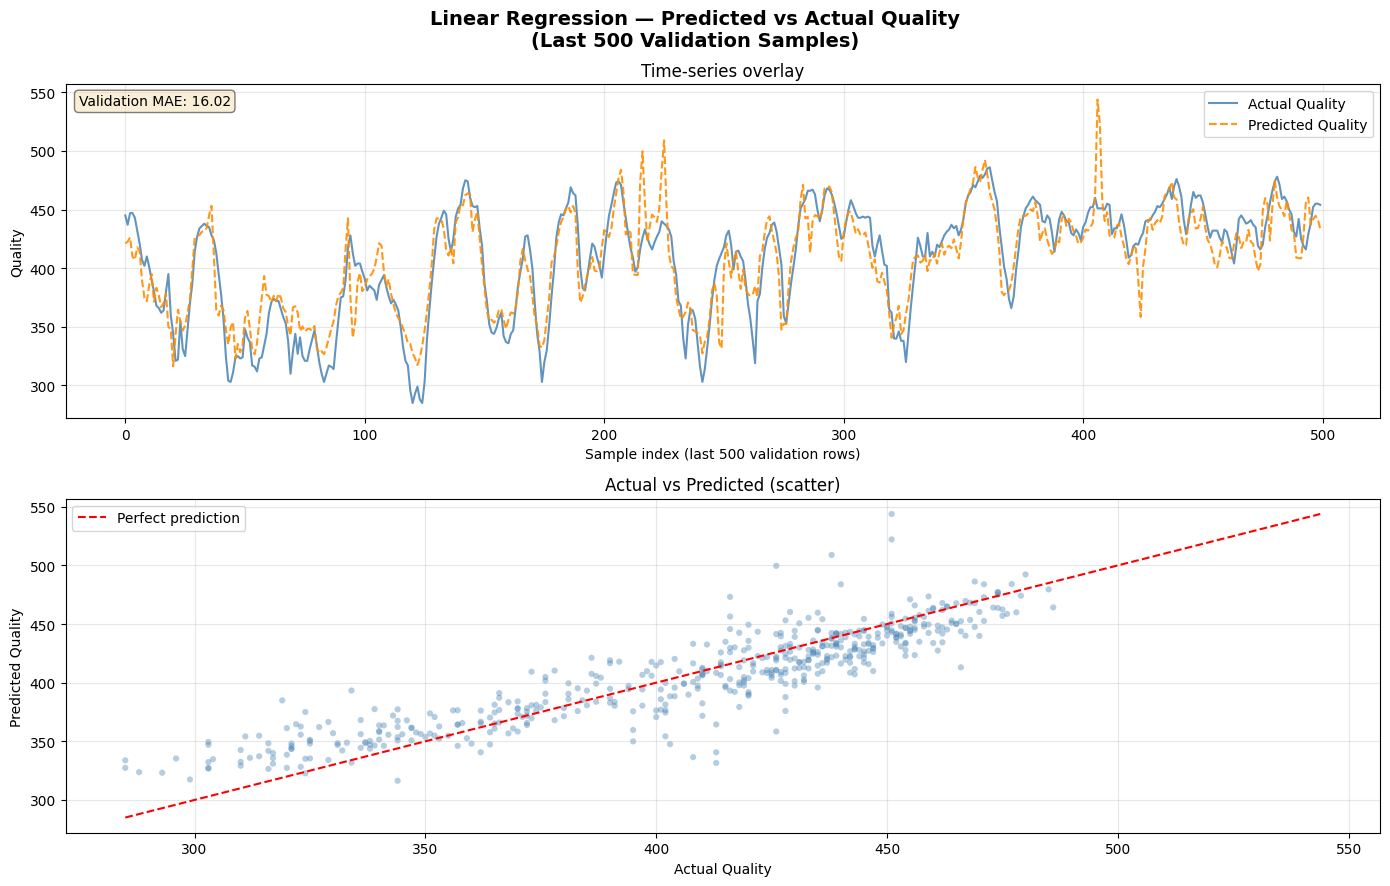

Plot saved to roasting_predictions.png


In [18]:
# Slice the last 500 rows of validation data
y_val_last500        = y_val.iloc[-500:].values
y_val_pred_last500   = y_val_pred[-500:]

x_axis = np.arange(len(y_val_last500))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Linear Regression — Predicted vs Actual Quality\n(Last 500 Validation Samples)',
             fontsize=14, fontweight='bold')

# ── Top panel: time-series overlay ──────────────────────────────────────────
ax1 = axes[0]
ax1.plot(x_axis, y_val_last500,     label='Actual Quality',    color='steelblue',  linewidth=1.5, alpha=0.85)
ax1.plot(x_axis, y_val_pred_last500, label='Predicted Quality', color='darkorange', linewidth=1.5, linestyle='--', alpha=0.9)
ax1.set_xlabel('Sample index (last 500 validation rows)')
ax1.set_ylabel('Quality')
ax1.set_title('Time-series overlay')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate MAE on plot
ax1.text(0.01, 0.97,
         f'Validation MAE: {mae_val:.2f}',
         transform=ax1.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=10)

# ── Bottom panel: scatter plot (actual vs predicted) ────────────────────────
ax2 = axes[1]
ax2.scatter(y_val_last500, y_val_pred_last500,
            alpha=0.4, edgecolors='none', color='steelblue', s=20)

# Perfect-prediction diagonal
lims = [min(y_val_last500.min(), y_val_pred_last500.min()),
        max(y_val_last500.max(), y_val_pred_last500.max())]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax2.set_xlabel('Actual Quality')
ax2.set_ylabel('Predicted Quality')
ax2.set_title('Actual vs Predicted (scatter)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roasting_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to roasting_predictions.png')

## 7. Results Summary

In [19]:
print('=' * 45)
print('         LINEAR REGRESSION RESULTS         ')
print('=' * 45)
print(f'  Training rows         : {len(X_train):>8,}')
print(f'  Validation rows       : {len(X_val):>8,}')
print(f'  Input features        : {len(feature_cols):>8}')
print('-' * 45)
print(f'  MAE — Train           : {mae_train:>8.4f}')
print(f'  MAE — Validation      : {mae_val:>8.4f}')
print('=' * 45)

         LINEAR REGRESSION RESULTS         
  Training rows         :   24,000
  Validation rows       :    5,001
  Input features        :       17
---------------------------------------------
  MAE — Train           :  15.7661
  MAE — Validation      :  16.0166


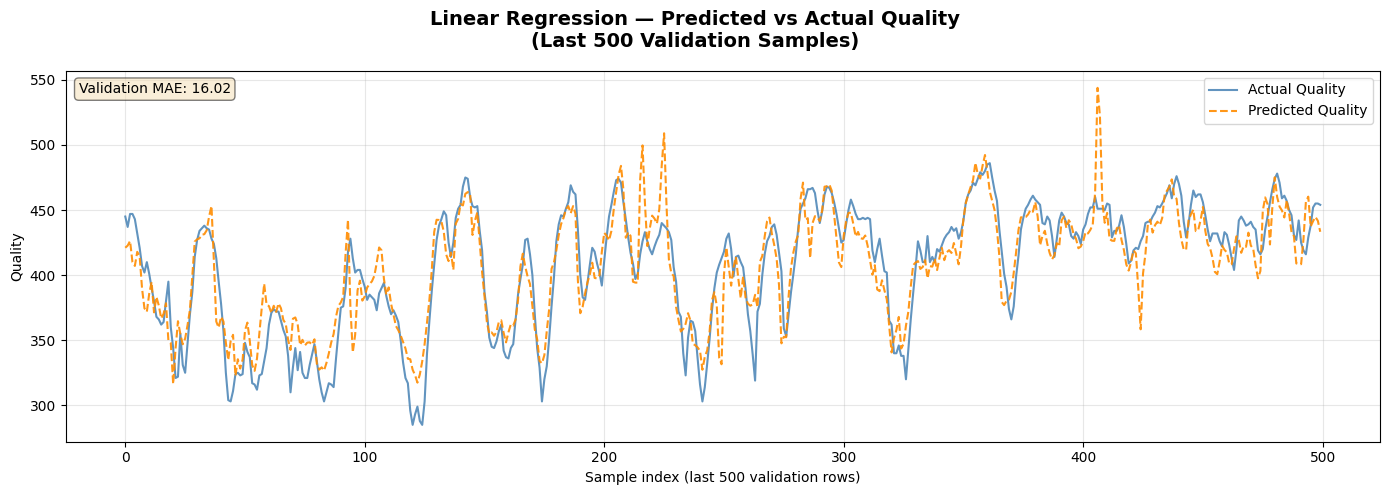

Plot saved to roasting_predictions.png


In [21]:
# Slice the last 500 rows of validation data
y_val_last500      = y_val.iloc[-500:].values
y_val_pred_last500 = y_val_pred[-500:]

x_axis = np.arange(len(y_val_last500))

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Linear Regression — Predicted vs Actual Quality\n(Last 500 Validation Samples)',
             fontsize=14, fontweight='bold')

ax.plot(x_axis, y_val_last500,      label='Actual Quality',    color='steelblue',  linewidth=1.5, alpha=0.85)
ax.plot(x_axis, y_val_pred_last500, label='Predicted Quality', color='darkorange', linewidth=1.5, linestyle='--', alpha=0.9)
ax.set_xlabel('Sample index (last 500 validation rows)')
ax.set_ylabel('Quality')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.01, 0.97,
        f'Validation MAE: {mae_val:.2f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10)

plt.tight_layout()
plt.savefig('roasting_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to roasting_predictions.png')